# **RIDGE regression - Training Window**

Marek Šugár

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import Lasso

# Ignore warnings
import warnings

warnings.filterwarnings("ignore")


In [2]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

In [3]:
TrainingDataFrame["Time_flow"] = np.arange(1, len(TrainingDataFrame)+1)
historic_columns.append("Time_flow")

# **LASSO regression**

In [4]:
performance_tracker = {}
performance_simple = {}
model_dominance = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 4 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []
    model_dominance[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    dominance_dates = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = Lasso(alpha=4.15, max_iter=3000)

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)

        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))
        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))

        if mean_absolute_percentage_error(Test_Target, prediction) <= mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]):
            dominance_dates.append(str(Stock_Data["Date"].iloc[window_start+training_length+prediction_length].date()))                                                        

        #print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))    
        
    performance_tracker[ticker] = MAPEs.copy()
    performance_simple[ticker] = AccuracyToSimple.copy()
    model_dominance[ticker] = dominance_dates.copy()


In [5]:
np.mean([np.mean(i) for i in performance_simple.values()])

np.float64(0.3616195551436515)

In [6]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [7]:
np.mean(list(mean_performances.values()))

np.float64(2.2967185903061456)

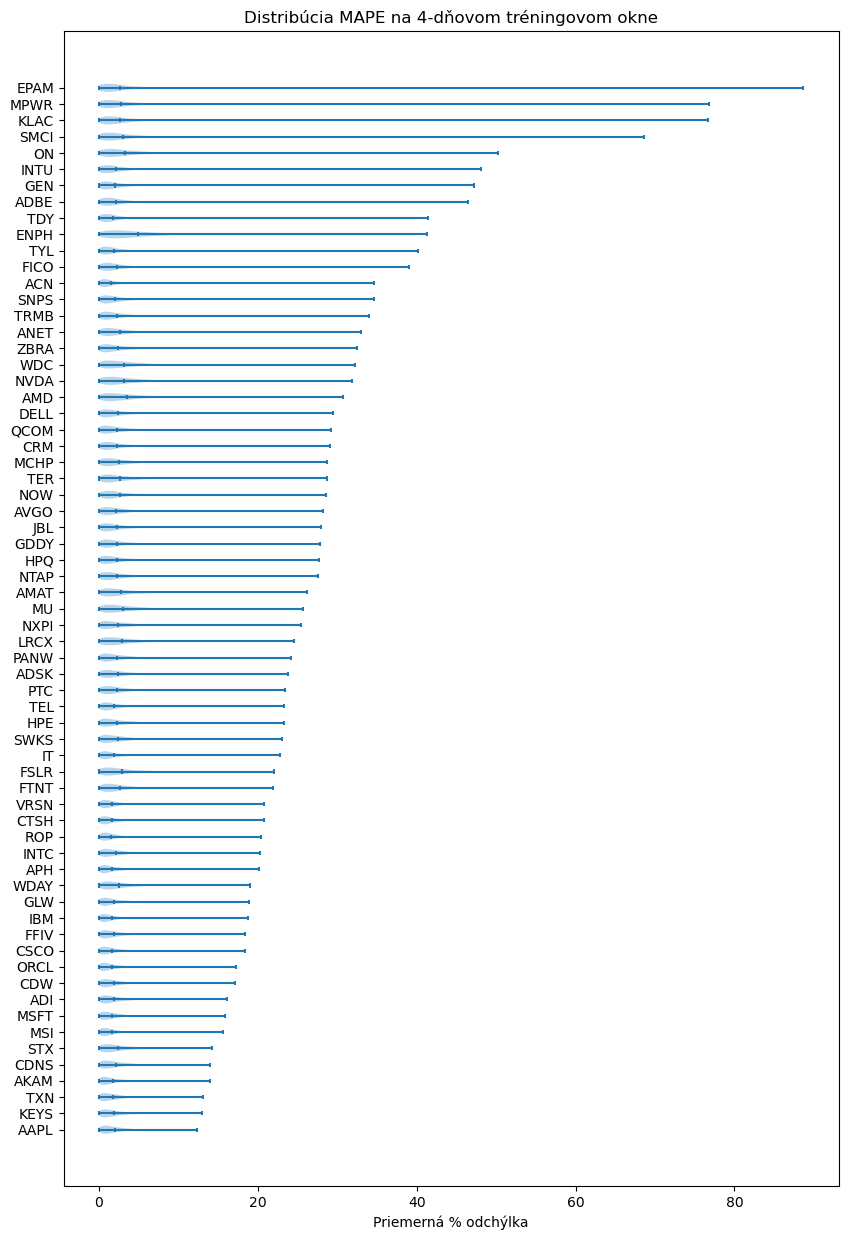

In [8]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

In [9]:
mean_performances

{'ROP': np.float64(1.482055309348823),
 'ACN': np.float64(1.5621291743757657),
 'IBM': np.float64(1.5804749171214254),
 'MSI': np.float64(1.6003022982439625),
 'CSCO': np.float64(1.6054359077355373),
 'ORCL': np.float64(1.6119090174717812),
 'APH': np.float64(1.66552316898781),
 'VRSN': np.float64(1.6731714430035658),
 'MSFT': np.float64(1.681568880510634),
 'CTSH': np.float64(1.6879568585451523),
 'AKAM': np.float64(1.7503281194479496),
 'TXN': np.float64(1.767722179468038),
 'TDY': np.float64(1.8170745036811378),
 'IT': np.float64(1.8473985484456237),
 'TYL': np.float64(1.8846485879203472),
 'TEL': np.float64(1.8916753245642908),
 'CDW': np.float64(1.895319412197026),
 'GLW': np.float64(1.914522910111208),
 'FFIV': np.float64(1.9313888999307274),
 'KEYS': np.float64(1.9345300730198793),
 'ADI': np.float64(1.947380384673889),
 'AAPL': np.float64(1.9576396034111723),
 'SNPS': np.float64(2.0043502308909336),
 'GEN': np.float64(2.05189286320171),
 'CDNS': np.float64(2.0885297490559496),


# **Date-wise model dominance over naive**

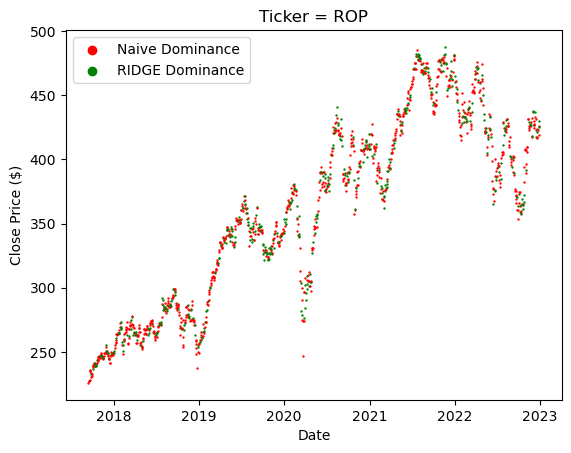

In [30]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ROP"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

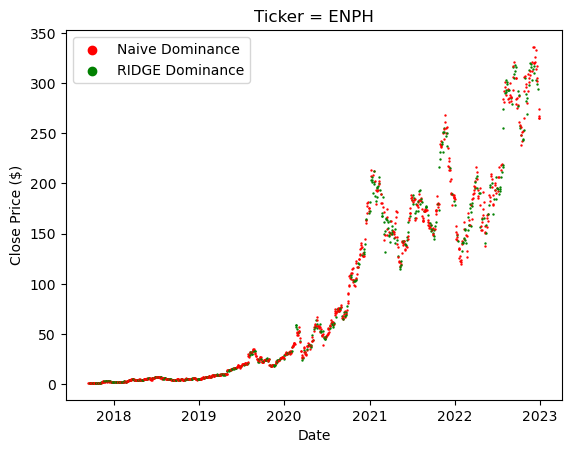

In [29]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ENPH"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

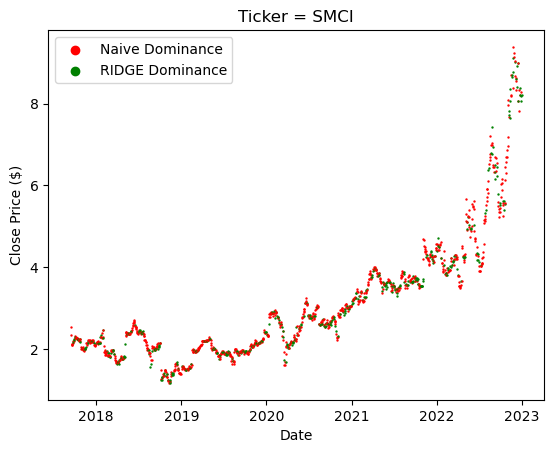

In [28]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "SMCI"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

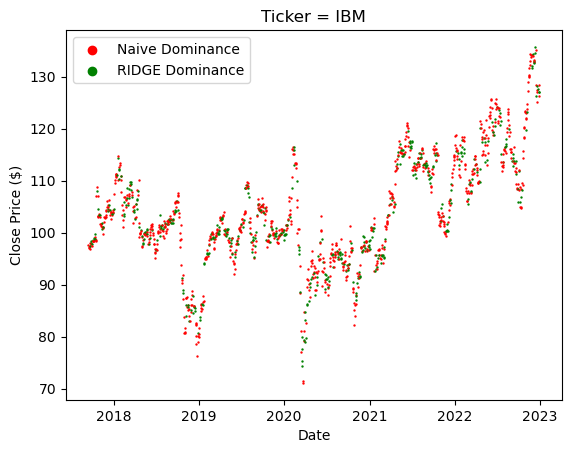

In [27]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "IBM"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

# **Analysis of dominance in detail**

In [14]:
# COVID
# We perform analysis of precision between February and March 2020 -> Covid recession

# Number of trading days -> 41 days
trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= "2020-02-01") & (TrainingDataFrame["Date"] <= "2020-03-31")]["Date"].values
trading_days = [str(i).split("T")[0] for i in trading_days]

covid_dominances = {}

for ticker in tickers["Ticker"]:
    counter = 0
    for day in model_dominance[ticker]:
        if day in trading_days:
            counter += 1
    covid_dominances[ticker] = counter*100 / len(trading_days)

print(np.mean(list(covid_dominances.values())))

38.68667917448405


In [15]:
sorted(covid_dominances.items(), key=lambda x: x[1], reverse=True)

[('KEYS', 58.53658536585366),
 ('TXN', 58.53658536585366),
 ('ADSK', 56.09756097560975),
 ('QCOM', 56.09756097560975),
 ('SWKS', 51.21951219512195),
 ('ADI', 48.78048780487805),
 ('CDW', 48.78048780487805),
 ('CSCO', 48.78048780487805),
 ('GLW', 48.78048780487805),
 ('INTC', 48.78048780487805),
 ('KLAC', 48.78048780487805),
 ('AAPL', 46.34146341463415),
 ('EPAM', 46.34146341463415),
 ('FICO', 46.34146341463415),
 ('TER', 46.34146341463415),
 ('AKAM', 43.90243902439025),
 ('APH', 43.90243902439025),
 ('AMAT', 43.90243902439025),
 ('ANET', 43.90243902439025),
 ('MU', 43.90243902439025),
 ('MPWR', 43.90243902439025),
 ('CRM', 43.90243902439025),
 ('DELL', 41.46341463414634),
 ('ORCL', 41.46341463414634),
 ('NOW', 41.46341463414634),
 ('TDY', 41.46341463414634),
 ('CDNS', 39.02439024390244),
 ('HPE', 39.02439024390244),
 ('HPQ', 39.02439024390244),
 ('IBM', 39.02439024390244),
 ('LRCX', 39.02439024390244),
 ('MCHP', 39.02439024390244),
 ('MSFT', 39.02439024390244),
 ('ON', 39.0243902439024

In [16]:
# Trumpove mecheche
# We perform analysis of precision between of April 2025 -> Trump's tarrifs

# Number of trading days -> 41 days
trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= "2025-04-01") & (TrainingDataFrame["Date"] <= "2025-04-30")]["Date"].values
trading_days = [str(i).split("T")[0] for i in trading_days]

trump_dominances = {}

for ticker in tickers["Ticker"]:
    counter = 0
    for day in model_dominance[ticker]:
        if day in trading_days:
            counter += 1
    trump_dominances[ticker] = counter*100 / len(trading_days)

print(np.mean(list(trump_dominances.values())))

0.0


In [17]:
sorted(trump_dominances.items(), key=lambda x: x[1], reverse=True)

[('ACN', 0.0),
 ('ADBE', 0.0),
 ('AMD', 0.0),
 ('AKAM', 0.0),
 ('APH', 0.0),
 ('ADI', 0.0),
 ('AAPL', 0.0),
 ('AMAT', 0.0),
 ('ANET', 0.0),
 ('ADSK', 0.0),
 ('AVGO', 0.0),
 ('CDNS', 0.0),
 ('CDW', 0.0),
 ('CSCO', 0.0),
 ('CTSH', 0.0),
 ('GLW', 0.0),
 ('DELL', 0.0),
 ('ENPH', 0.0),
 ('EPAM', 0.0),
 ('FFIV', 0.0),
 ('FICO', 0.0),
 ('FSLR', 0.0),
 ('FTNT', 0.0),
 ('IT', 0.0),
 ('GEN', 0.0),
 ('GDDY', 0.0),
 ('HPE', 0.0),
 ('HPQ', 0.0),
 ('IBM', 0.0),
 ('INTC', 0.0),
 ('INTU', 0.0),
 ('JBL', 0.0),
 ('KEYS', 0.0),
 ('KLAC', 0.0),
 ('LRCX', 0.0),
 ('MCHP', 0.0),
 ('MU', 0.0),
 ('MSFT', 0.0),
 ('MPWR', 0.0),
 ('MSI', 0.0),
 ('NTAP', 0.0),
 ('NVDA', 0.0),
 ('NXPI', 0.0),
 ('ON', 0.0),
 ('ORCL', 0.0),
 ('PANW', 0.0),
 ('PTC', 0.0),
 ('QCOM', 0.0),
 ('ROP', 0.0),
 ('CRM', 0.0),
 ('STX', 0.0),
 ('NOW', 0.0),
 ('SWKS', 0.0),
 ('SMCI', 0.0),
 ('SNPS', 0.0),
 ('TEL', 0.0),
 ('TDY', 0.0),
 ('TER', 0.0),
 ('TXN', 0.0),
 ('TRMB', 0.0),
 ('TYL', 0.0),
 ('VRSN', 0.0),
 ('WDC', 0.0),
 ('WDAY', 0.0),
 ('ZB

**Year-wise dominance**

In [25]:
years = [str(i) for i in range(2017, 2023)]
dominances = []

for year in years:
    trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= f"{year}-01-01") & (TrainingDataFrame["Date"] <= f"{year}-12-31")]["Date"].values
    trading_days = [str(i).split("T")[0] for i in trading_days]

    year_dominances = {}

    for ticker in tickers["Ticker"]:
        counter = 0
        for day in model_dominance[ticker]:
            if day in trading_days:
                counter += 1
        year_dominances[ticker] = counter*100 / len(trading_days)

    dominances.append(np.mean(list(year_dominances.values())))
    print(year, np.mean(list(year_dominances.values())))

2017 32.86902286902287
2018 34.085197670855045
2019 35.378510378510384
2020 37.64670112496199
2021 37.65567765567765
2022 36.248850750842784


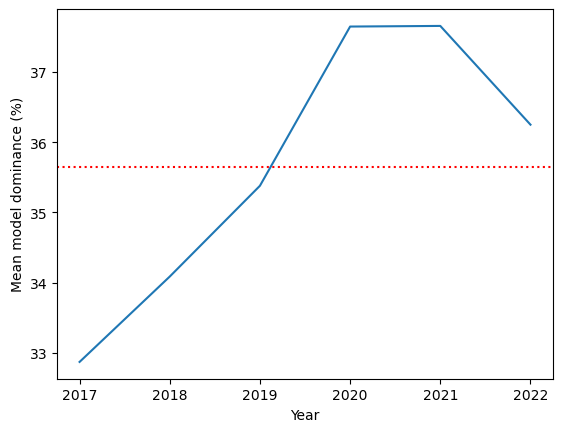

In [26]:
plt.plot(years, dominances)

plt.xlabel("Year")
plt.ylabel("Mean model dominance (%)")

plt.axhline(np.mean(dominances), linestyle="dotted", color="red")

plt.show()

# **LASSO Stock-wise optimality**

In [20]:
optimal_parameters = {}
with open("LASSO/LASSO_StockWise.txt") as file:
    for i in file.readlines():
        data = i.split()
        optimal_parameters[data[0]] = float(data[1])

In [22]:
performance_tracker = {}
performance_simple = {}
model_dominance = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 4 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []
    model_dominance[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    dominance_dates = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = Lasso(alpha=optimal_parameters[ticker])

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)
        
        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))
        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        
        if mean_absolute_percentage_error(Test_Target, prediction) <= mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]):
            dominance_dates.append(str(Stock_Data["Date"].iloc[window_start+training_length+prediction_length].date()))                                                        

        print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))    
    
    performance_simple[ticker] = AccuracyToSimple.copy()
    performance_tracker[ticker] = MAPEs.copy()
    model_dominance[ticker] = dominance_dates.copy()

ACN 0.0676743567360113
ACN 0.5946502987607587
ACN 0.6080030633951634
ACN 0.6156894161177433
ACN 0.5488808647952917
ACN 0.7812669905968671
ACN 1.4215063706361382
ACN 0.5740588494885623
ACN 1.2048374036761582
ACN 0.0813440345986971
ACN 0.9102748218109971
ACN 0.7210784924071736
ACN 1.1095762664351143
ACN 0.99258284821629
ACN 0.12050239877763678
ACN 1.6397085958894342
ACN 1.1098972352317915
ACN 0.634487640533891
ACN 0.03608763969580346
ACN 0.20468987869144173
ACN 0.7429050456140156
ACN 1.2267026106050702
ACN 0.80204991092836
ACN 0.14036358651406947
ACN 1.4682152285933607
ACN 1.5830578888985445
ACN 2.0501736935651707
ACN 1.3678691729069226
ACN 0.04567459449210285
ACN 0.16437891928528883
ACN 0.31895918462143313
ACN 0.7150756086850969
ACN 0.5089432023305241
ACN 0.06270411894356019
ACN 0.8040346150901618
ACN 0.1807669450226615
ACN 0.10249923059197341
ACN 0.07465040256782471
ACN 0.570868625057524
ACN 0.07621678143968272
ACN 1.892303928466537
ACN 0.27842550315984527
ACN 0.779563282188957
ACN 1.4

In [ ]:
means_prevalences = [np.mean(i) for i in performance_simple.values()]
np.mean(means_prevalences)
# 0.444066099148723

np.float64(0.35806016717383765)

In [ ]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [ ]:
np.mean(list(mean_performances.values()))

np.float64(2.27066587724895)

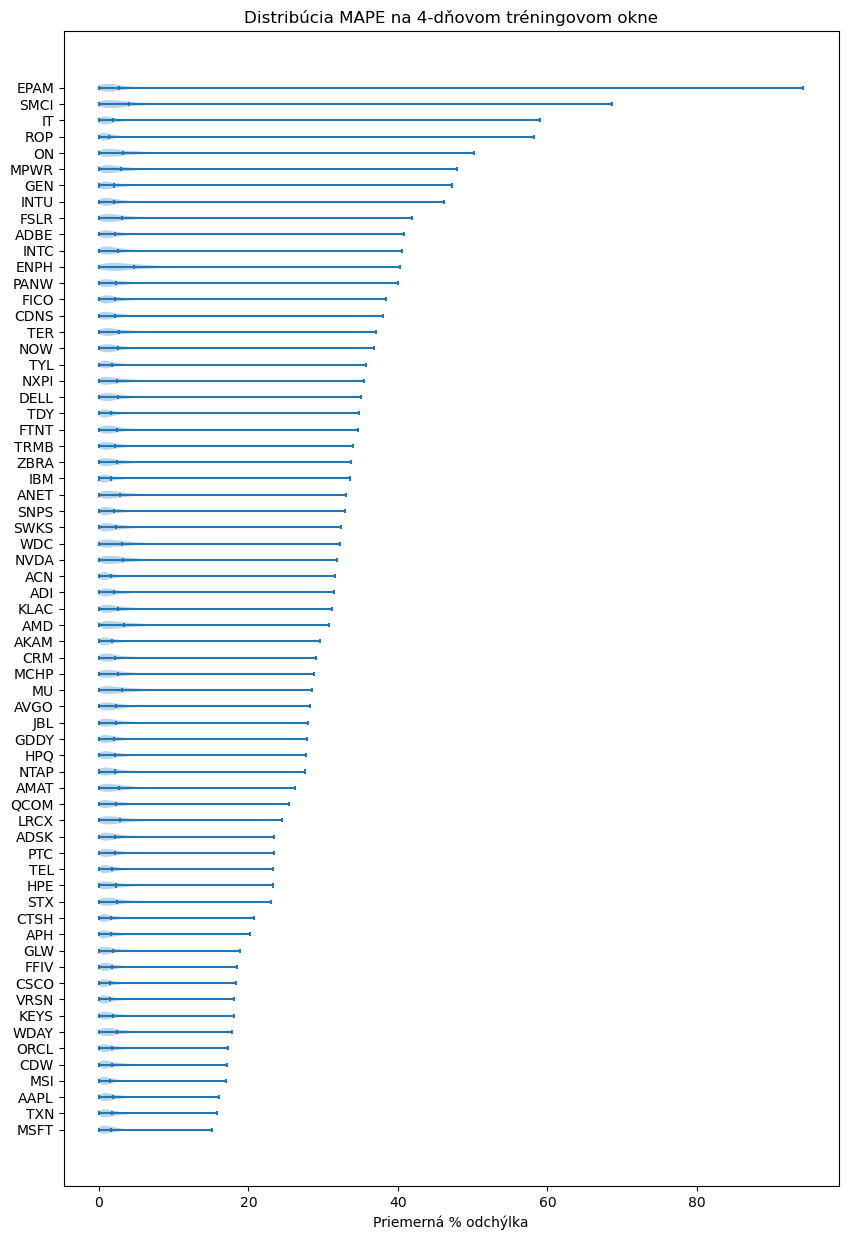

In [ ]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()